# 00 KPI Engineering
Create all required KPIs, bins, quality checks, summaries, and exports.

In [1]:
import warnings
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "utils" / "utils.py").exists():
    if (PROJECT_ROOT / "notebooks" / "utils" / "utils.py").exists():
        PROJECT_ROOT = PROJECT_ROOT / "notebooks"
    elif (PROJECT_ROOT.parent / "utils" / "utils.py").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from utils.utils import ensure_project_dirs, load_raw_dataset, clean_dataset, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR
from utils.features import engineer_kpis, build_post_feature_sets, aggregate_business_features
from utils.evaluation import regression_metrics, rank_models
from utils.visualization import set_plot_style, save_figure

set_plot_style()
ensure_project_dirs()
RAW_DATA_PATH = Path("../data/vanilla_processed.json")

if not RAW_DATA_PATH.exists():
    RAW_DATA_PATH = PROJECT_ROOT / "synthetic_generator" / "synthetic_social_media_posts.csv"
KPI_PATH = PROCESSED_DIR / "kpi_dataset.csv"

## Load and Clean Data

In [2]:
def load_raw_dataset(path):
    data_path = Path(path)

    if not data_path.exists():
        raise FileNotFoundError(f"Dataset not found at {data_path}")

    if data_path.suffix.lower() == ".csv":
        return pd.read_csv(data_path)

    if data_path.suffix.lower() == ".json":
        return pd.read_json(data_path)

    raise ValueError(f"Unsupported file type: {data_path.suffix}")


raw_df = load_raw_dataset(RAW_DATA_PATH)
clean_df = clean_dataset(raw_df)

print("Raw:", raw_df.shape, "Clean:", clean_df.shape)

display(clean_df.head())

Raw: (124, 22) Clean: (124, 24)


,business_name,sector,followers_count,post_date,day_of_week,month,post_type,caption_text,caption_length,hashtags_count,...,language,CTA_present,promo_post,mentions_location,religious_theme,patriotic_theme,arabic_dialect_style,sponsored,posting_hour,discount_percent
0,Vanilla Palestine,Cafes/Restaurants,139000,2025-02-05,Wednesday,2.0,reel,شاركونا إجابتكم بالتعليقات 👇 #فانيلا_اليوم_وكل...,83,2,...,Arabic,True,False,False,False,False,True,0,0.0,0.0
1,Vanilla Palestine,Cafes/Restaurants,139000,2025-02-04,Tuesday,2.0,reel,What’s your favorite cake ❤️🍰? #VANILLA_Today_...,65,1,...,English,True,False,False,False,False,False,0,0.0,0.0
2,Vanilla Palestine,Cafes/Restaurants,139000,2025-02-01,Saturday,2.0,reel,كل يوم له بداية… وأجمل بداية بطاقة إيجابية #فا...,72,1,...,Arabic,False,False,False,False,False,True,0,0.0,0.0
3,Vanilla Palestine,Cafes/Restaurants,139000,2025-01-24,Friday,1.0,reel,ومن أهم فوائدها إنها تذهب الحزن.. التلبينة الن...,239,2,...,Arabic,False,False,False,True,False,True,0,0.0,0.0
4,Vanilla Palestine,Cafes/Restaurants,139000,2023-10-03,Tuesday,10.0,reel,استمر بالأكل أنت بأمان 😜🤤 #فانيلا_اليوم_وكل_يو...,142,10,...,Mixed,False,False,False,False,False,True,0,0.0,0.0


## Engineer KPIs and Validate Division Safety

In [3]:
clean_df.isna().sum()

business_name           0
sector                  0
followers_count         0
post_date               0
day_of_week             0
month                   0
post_type               0
caption_text            0
caption_length          0
hashtags_count          0
emoji_count             0
likes_count             0
comments_count          0
views_count             0
language                0
CTA_present             0
promo_post              0
mentions_location       0
religious_theme         0
patriotic_theme         0
arabic_dialect_style    0
sponsored               0
posting_hour            0
discount_percent        0
dtype: int64

In [4]:
df = engineer_kpis(clean_df)
df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")
rate_cols = ["engagement_rate", "like_rate", "comment_rate", "view_rate", "view_engagement_rate"]
invalid = {c: int(np.isinf(df[c]).sum() + df[c].isna().sum()) for c in rate_cols}
print("Invalid rate values:", invalid)
print("followers_count==0:", int((df["followers_count"] == 0).sum()))
print("views_count==0:", int((df["views_count"] == 0).sum()))
# Weekly KPI
df["week"] = (
    df["post_date"]
    .dt.to_period("W")
    .astype(str)
)
display(df.head())

Invalid rate values: {'engagement_rate': 0, 'like_rate': 0, 'comment_rate': 0, 'view_rate': 0, 'view_engagement_rate': 0}
followers_count==0: 0
views_count==0: 0


,business_name,sector,followers_count,post_date,day_of_week,month,post_type,caption_text,caption_length,hashtags_count,...,is_reel,posting_time_bin,caption_length_bin,hashtags_count_bin,emoji_count_bin,engagement_level,business_size_bin,high_engagement,high_view_rate,high_comment_rate
0,Vanilla Palestine,Cafes/Restaurants,139000,2025-02-05,Wednesday,2,reel,شاركونا إجابتكم بالتعليقات 👇 #فانيلا_اليوم_وكل...,83,2,...,1,night,medium,few,few,low,medium,0,0,0
1,Vanilla Palestine,Cafes/Restaurants,139000,2025-02-04,Tuesday,2,reel,What’s your favorite cake ❤️🍰? #VANILLA_Today_...,65,1,...,1,night,medium,few,few,low,medium,0,0,0
2,Vanilla Palestine,Cafes/Restaurants,139000,2025-02-01,Saturday,2,reel,كل يوم له بداية… وأجمل بداية بطاقة إيجابية #فا...,72,1,...,1,night,medium,few,none,low,medium,0,0,0
3,Vanilla Palestine,Cafes/Restaurants,139000,2025-01-24,Friday,1,reel,ومن أهم فوائدها إنها تذهب الحزن.. التلبينة الن...,239,2,...,1,night,long,few,none,high,medium,1,0,0
4,Vanilla Palestine,Cafes/Restaurants,139000,2023-10-03,Tuesday,10,reel,استمر بالأكل أنت بأمان 😜🤤 #فانيلا_اليوم_وكل_يو...,142,10,...,1,night,long,many,few,medium,medium,0,0,0


## Summary Tables and Exports

In [5]:
df.isna().sum()

business_name           0
sector                  0
followers_count         0
post_date               0
day_of_week             0
month                   0
post_type               0
caption_text            0
caption_length          0
hashtags_count          0
emoji_count             0
likes_count             0
comments_count          0
views_count             0
language                0
CTA_present             0
promo_post              0
mentions_location       0
religious_theme         0
patriotic_theme         0
arabic_dialect_style    0
sponsored               0
posting_hour            0
discount_percent        0
engagement              0
engagement_rate         0
like_rate               0
comment_rate            0
view_rate               0
view_engagement_rate    0
week                    0
is_video                0
is_reel                 0
posting_time_bin        0
caption_length_bin      0
hashtags_count_bin      0
emoji_count_bin         0
engagement_level        0
business_siz

,sector,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
0,Cafes/Restaurants,124,1224.209677,0.010215,1.92867,0.002027


,business_name,sector,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
0,Vanilla Palestine,Cafes/Restaurants,124,1224.209677,0.010215,1.92867,0.002027


,post_type,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
1,reel,110,1300.218182,0.010942,2.122861,0.002278
0,post,14,627.000000,0.004511,0.402878,0.000048


,week,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
14,2025-02-10/2025-02-16,1,6608.00,0.075693,6.174112,0.037801
20,2025-03-24/2025-03-30,1,3983.00,0.045624,11.454754,0.022910
25,2025-05-05/2025-05-11,2,3958.00,0.045338,6.597938,0.022910
13,2025-02-03/2025-02-09,4,5404.50,0.038881,1.475180,0.001331
21,2025-04-07/2025-04-13,1,3211.00,0.036781,5.853379,0.018328
22,2025-04-14/2025-04-20,1,1497.00,0.017148,11.454754,0.008591
34,2026-02-02/2026-02-08,2,2137.50,0.015378,1.726619,0.000072
15,2025-02-17/2025-02-23,4,1755.75,0.014975,3.393691,0.003173
11,2025-01-20/2025-01-26,3,1962.00,0.014115,1.812950,0.000094
37,2026-03-02/2026-03-08,2,1765.00,0.012698,1.996403,0.000378


Saved as ../data/data_processed.json


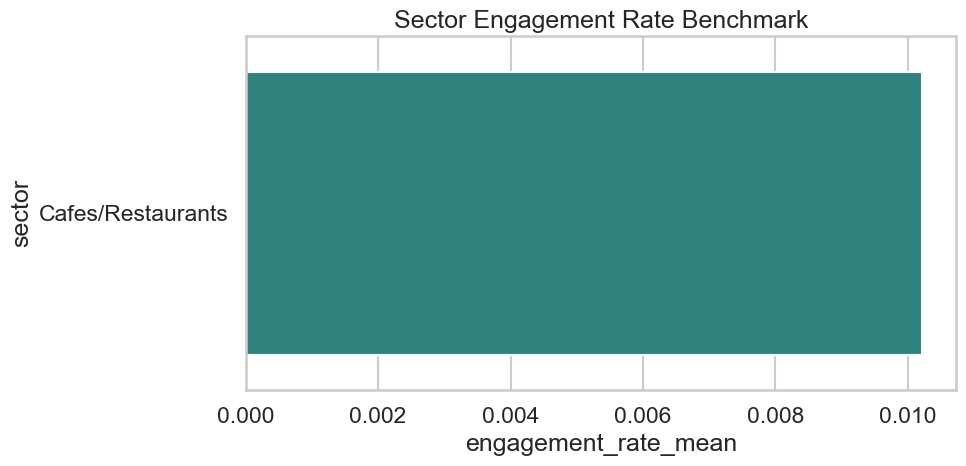

Insight: Top sector is Cafes/Restaurants with engagement rate 0.0102.


In [6]:
if "week" not in df.columns:
    df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")
    df["week"] = df["post_date"].dt.to_period("W").astype(str)
summaries = {}
for key, grp in {
    "sector": ["sector"],
    "business": ["business_name", "sector"],
    "post_type": ["post_type"],
    "week": ["week"],
    
}.items():
    summaries[key] = df.groupby(grp, as_index=False).agg(
        posts_count=("business_name", "size"),
        engagement_mean=("engagement", "mean"),
        engagement_rate_mean=("engagement_rate", "mean"),
        view_rate_mean=("view_rate", "mean"),
        comment_rate_mean=("comment_rate", "mean"),
    ).sort_values("engagement_rate_mean", ascending=False)
    display(summaries[key].head(10))

# df.to_json(, index=False)
df.loc[:, 'followers_count'] = 87300
df.to_json(
    PROCESSED_DIR / "vanilla_kpi_dataset.json",
    orient="records",
    force_ascii=False,
    indent=4
)

print("Saved as ../data/data_processed.json")
for k, v in summaries.items():
    v.to_csv(REPORTS_DIR / f"kpi_summary_{k}.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = summaries["sector"].head(15)
sns.barplot(data=plot_df, x="engagement_rate_mean", y="sector", ax=ax, palette="viridis")
ax.set_title("Sector Engagement Rate Benchmark")
save_figure(fig, FIGURES_DIR, "kpi_sector_engagement_rate.png")
plt.show()

top_sector = summaries["sector"].iloc[0]
print(f"Insight: Top sector is {top_sector['sector']} with engagement rate {top_sector['engagement_rate_mean']:.4f}.")

In [7]:
df['followers_count'].isna().sum()

np.int64(0)

In [8]:
df.isna().sum()

business_name           0
sector                  0
followers_count         0
post_date               0
day_of_week             0
month                   0
post_type               0
caption_text            0
caption_length          0
hashtags_count          0
emoji_count             0
likes_count             0
comments_count          0
views_count             0
language                0
CTA_present             0
promo_post              0
mentions_location       0
religious_theme         0
patriotic_theme         0
arabic_dialect_style    0
sponsored               0
posting_hour            0
discount_percent        0
engagement              0
engagement_rate         0
like_rate               0
comment_rate            0
view_rate               0
view_engagement_rate    0
week                    0
is_video                0
is_reel                 0
posting_time_bin        0
caption_length_bin      0
hashtags_count_bin      0
emoji_count_bin         0
engagement_level        0
business_siz